## Set-up
* importing necessary packages and defining parameters

In [1]:
import numpy as np
import cv2
import math 
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
from matplotlib import colors
from scipy.signal import argrelextrema
import pandas as pd
import csv
import os
from scipy.ndimage import gaussian_filter1d
import re

In [2]:
extension_factor = 1.1
step_size = 2
max_width = 2048
overlap_threshold = 0.3
weight_epithelium_coverage = 0.8
weight_background_pixels = 0.2
mask_smoothing = True
window_size=21
smoothing_sigma=50
scale_factor=0.25

## *** IMPORTANT *** 
This code relies on the slice images and masks being in a folder called `testing_slices/`

Inside that folder, create a folder called `patch_outputs/` for the patches to be exported into

In [18]:
image_folder = './testing_slices_fix'
image_files = [f for f in os.listdir(image_folder) if f.startswith('h&e')]

## Final patching code 

In [ ]:
def gaussian_smooth_contour(contour, window_size=window_size, sigma=smoothing_sigma):
    """
    Smooths a contour by applying a Gaussian kernel to the x and y coordinates.
    
    Args:
        contour: A 2D array of contour points of shape (N, 2).
        window_size: The size of the Gaussian kernel (must be odd).
        sigma: Standard deviation of the Gaussian kernel.
        
    Returns:
        Smoothed contour as an integer array of shape (N, 2).
    """
    contour = contour.squeeze()  # shape (N, 2)
    N = len(contour)
    
    # Create a Gaussian kernel.
    x_range = np.arange(window_size) - window_size // 2
    kernel = np.exp(-(x_range**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    
    # Circularly pad the contour coordinates.
    padded_x = np.pad(contour[:, 0], (window_size // 2, window_size // 2), mode='wrap')
    padded_y = np.pad(contour[:, 1], (window_size // 2, window_size // 2), mode='wrap')
    
    # Convolve to smooth the x and y coordinates.
    smoothed_x = np.convolve(padded_x, kernel, mode='valid')
    smoothed_y = np.convolve(padded_y, kernel, mode='valid')
    
    smoothed_contour = np.stack([smoothed_x, smoothed_y], axis=-1)
    return np.round(smoothed_contour).astype(np.int32)

def compute_smoothed_mask(binary_mask, window_size=window_size, sigma=smoothing_sigma, scale_factor=scale_factor):
    """
    Compute a smoothed version of a binary mask by:
      1. Downscaling the mask.
      2. Extracting contours using RETR_TREE.
      3. Smoothing each contour with a Gaussian kernel.
      4. Upscaling the smoothed contours back to the original resolution.
      5. Drawing the contours into a new binary mask.
    
    Args:
      binary_mask (np.ndarray): Original binary mask (0/255).
      window_size (int): Window size for Gaussian smoothing.
      sigma (float): Sigma value for the Gaussian kernel.
      scale_factor (float): Downscaling factor.
    
    Returns:
      np.ndarray: A binary mask of the same dimensions as binary_mask, but with smoothed boundaries.
    """
    orig_h, orig_w = binary_mask.shape
    # Downscale the mask for processing.
    small_mask = cv2.resize(binary_mask, (0, 0), fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)
    small_h, small_w = small_mask.shape

    # Extract contours from the downscaled mask.
    contours, hierarchy = cv2.findContours(small_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
    # Prepare an empty mask for the final result.
    smoothed_mask = np.zeros_like(binary_mask)
    # Compute scaling factors to upscale the smoothed contours.
    scale_x = orig_w / small_w
    scale_y = orig_h / small_h

    for i, cnt in enumerate(contours):
        cnt = cnt.squeeze()  # Remove extra dimensions.
        if cnt.ndim != 2 or len(cnt) < 3:
            continue
        # Ensure the contour is closed.
        if not np.array_equal(cnt[0], cnt[-1]):
            cnt = np.vstack([cnt, cnt[0]])
        # Smooth the contour using your Gaussian smoothing function.
        smooth_cnt = gaussian_smooth_contour(cnt, window_size=window_size, sigma=sigma)
        # Upscale the smoothed contour to original resolution.
        smooth_cnt = (smooth_cnt.astype(np.float32) * np.array([scale_x, scale_y])).astype(np.int32)
        smooth_cnt = smooth_cnt.reshape((-1, 1, 2))
        # Use hierarchy info: if the contour has no parent, it’s an outer boundary.
        if hierarchy[0][i][3] == -1:
            cv2.drawContours(smoothed_mask, [smooth_cnt], -1, 255, -1)
        else:
            cv2.drawContours(smoothed_mask, [smooth_cnt], -1, 0, -1)
    
    return smoothed_mask

def get_contours(binary_image):
    '''Find all external contours of an image, handling hierarchy correctly for both single and nested structures.'''

    contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # If no contours are found, return an empty list
    if hierarchy is None or len(contours) == 0:
        print("No contours found.")
        return []

    hierarchy = hierarchy[0]
    external_contours = []

    for i in range(len(contours)):
        if hierarchy[i][3] == -1:  # Check if contour has no parent (true external)
            external_contours.append(np.roll(contours[i], 0, axis=0))

    # If external contours seem incomplete (indicating nested structures exist), use the John's method
    if len(external_contours) < len(contours):  
        masks = []
        contour_indices = np.arange(0, hierarchy.shape[0], 1)

        while contour_indices.size != 0:
            current = contour_indices[0]
            contour_indices = np.delete(contour_indices, np.argwhere(contour_indices == current))

            # Create a mask for the contour
            mask = np.zeros_like(binary_image)
            cv2.drawContours(mask, contours, current, 255, 1)

            # Draw child contours inside the mask
            for j in np.argwhere(hierarchy[:, 3] == current).ravel():
                contour_indices = np.delete(contour_indices, np.argwhere(contour_indices == j))
                cv2.drawContours(mask, contours, j, 255, 1)

            masks.append(mask)

        # Extract external contours from the masks
        for mask in masks:
            extracted_contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            external_contours.extend(extracted_contours)

    unique_contours = []
    for c in external_contours:
        if not any(np.array_equal(c, u) for u in unique_contours):
            unique_contours.append(c)

    return unique_contours

def better_normals(contours,binary_image):
    contours = [contour.reshape(-1, 2).astype(np.float32) for contour in contours]

    # Compute sigma values for Gaussian smoothing
    sigmas = np.array([max(len(contour) // 90, 1) for contour in contours])  # Avoid sigma=0

    # Apply Gaussian smoothing to X and Y coordinates
    smoothed_contours = [
        np.column_stack((gaussian_filter1d(contour[:, 0], sigma, mode='constant'),
                         gaussian_filter1d(contour[:, 1], sigma, mode='constant')))
        for contour, sigma in zip(contours, sigmas)
    ]

    # Compute gradients (tangents)
    gradients = [np.gradient(contour, axis=0) for contour in smoothed_contours]

    # Normalize tangents to get unit tangent vectors
    tangent_units = [tangent / (np.linalg.norm(tangent, axis=1, keepdims=True) + 1e-8) for tangent in gradients]

    # Rotate tangents to get normals
    normals = [np.column_stack((-tangent[:, 1], tangent[:, 0])) for tangent in tangent_units]

    return normals

# CHANGED

def better_normals(contours, binary_image):
    """
    Calculate normal vectors with dynamic smoothing based on contour complexity
    """
    all_normals = []
    
    def estimate_curvature_complexity(points):
        """Estimate complexity of contour based on curvature variations"""
        if len(points) < 5:
            return 1
        
        diffs = np.gradient(points, axis=0)
        curvature = np.linalg.norm(np.gradient(diffs, axis=0), axis=1)
        
        # Count number of local maxima in curvature (sharp points)
        peaks = argrelextrema(curvature, np.greater)[0]
        
        # Return peaks/points ratio as measure of complexity
        return len(peaks) / len(points)
    
    for contour in contours:
        # Reshape contour into point pairings
        points = contour.reshape(-1, 2).astype(np.float32)
        
        # Calculate dynamic sigma based on contour complexity
        complexity = estimate_curvature_complexity(points)
        sigma = max(len(contour) * complexity // 20, 1)
        print(f'Sigma: {sigma}, Complexity: {complexity:.5f}')
        
        # Apply Gaussian smoothing BEFORE gradient calculation
        smoothed_points = gaussian_filter1d(points, sigma, axis=0) 
        
        # Calculate gradients on smoothed points
        gradients = np.gradient(smoothed_points, axis=0)
        
        # Normalize to get unit tangents
        norms = np.linalg.norm(gradients, axis=1, keepdims=True)
        tangent_unit = gradients / (norms + 1e-8)
        
        # Compute normals from tangents
        normals = np.column_stack((-tangent_unit[:, 1], tangent_unit[:, 0]))
        all_normals.append(normals)
        
    return all_normals

def calculate_patch_corners(point, normal, binary_image, extension_factor=1.0, step_size=4, max_length=2048):
    """
    Calculate the corners of a square patch using epithelium width along the normal.

    Args:
        point (np.ndarray): The point on the contour.
        normal (np.ndarray): The normal vector at the point.
        binary_image (np.ndarray): Binary mask of the tissue.
        extension_factor (float): Factor to slightly enlarge the patch (e.g., 1.1 for 10% increase).
        step_size (int): Step size for checking tissue boundaries along the normal.
        max_length (int): Maximum distance to search for epithelium width.

    Returns:
        np.ndarray: The four corners of the square patch.
        int: The computed patch height.
    """
    height, width = binary_image.shape
    point = point.astype(int)

    # generating forward and backward points along the normal
    steps = np.arange(0, max_length, step_size)[:, None]
    points = np.clip(point - steps * normal, 0, [width - 1, height - 1]).astype(int)

    # extracting pixel values along the normal path
    values = binary_image[points[:, 1], points[:, 0]]

    # finding the first background pixel (where value == 0)
    stop = np.where(values == 0)[0]

    # computing distances
    width = stop[0] * step_size if stop.size > 0 else max_length

    # computing total epithelium width and adjust for stroma extension
    extended_length = int(width * extension_factor)
    
    half_size = extended_length // 2 

    # computing tangent vector (perpendicular to normal)
    tangent = np.array([-normal[1], normal[0]])

    # defining square corners (same logic as `calculate_square_corners`)
    corners = np.array([
        point + (tangent * half_size),
        point - (tangent * half_size),
        point - (tangent * half_size) - (normal * extended_length),
        point + (tangent * half_size) - (normal * extended_length)
    ])

    return corners, extended_length

def draw_patches(image, patch_list, color = [255,0,0], thickness = 20):
    patches_on_slice = image.copy()
    for squares in patch_list:
        for square in squares:
            points=square.astype(np.int32)
            cv2.polylines(patches_on_slice,[points],isClosed=True,color=color,thickness=thickness)
    return patches_on_slice

def process_contours(slice_details,binary_image,overlap_thresh=0.3):
    """
    Main function to process multiple contours and generate aligned squares along them.
    
    Args:
        image (np.ndarray): Original image
        binary_image (np.ndarray): Binary mask of the shapes
        overlap_thresh (float): Maximum allowed overlap between squares        
    Returns:
        tuple: (processed image, contours, squares_list)
    """
    contours=get_contours(binary_image)
    
    if not contours:
        return TypeError('No contours found')
    
    #Condition check for square creation
    #normals=calculate_contour_normals(contours,smoothing_size)
    normals=better_normals(contours,binary_image)
    final_squares_list, patch_length_list = create_smarter_squares(contours,normals,binary_image,overlap_thresh=overlap_thresh)

    # Add this line to fix small patches
    tissue_slice = cv2.cvtColor(cv2.imread(slice_details), cv2.COLOR_BGR2RGB)

    result = draw_patches(tissue_slice,final_squares_list)
    
    return result, contours, final_squares_list


def patch_overlap(square1,square2):

    square1 = Polygon(square1)
    square2 = Polygon(square2)

    if not square1.intersects(square2):
        return 0
    
    intersection_area = square1.intersection(square2).area
    smallest_area = min(square1.area,square2.area)
    return intersection_area/smallest_area


# def create_smarter_squares(contours,normals,binary_image,overlap_thresh):
#     '''Create squares that meet overlap thresh with last square'''
#     return_squares=[]
#     all_patch_lengths = []
    
#     #Loop over all contours and get corresponding normals to point
#     for contour, contour_normals in zip(contours,normals):
#         points=contour.reshape(-1,2)
#         squares=[]
#         contour_patch_lengths = []
#         last_square=None

#         #Go over points, evaluating if next square's corner falls outside of range of last square
#         for i,point in enumerate(points):

#             corners,length=calculate_patch_corners(point,contour_normals[i],binary_image)

#             #Prevent poorly sized squares
#             #Finding rough area approximation in terms of patch length
#             side_length = np.sqrt(cv2.contourArea(contour))
#             #Approximately: Want squares less than 50% of contour area, and minimum of 2% area
#             if length>side_length*.50 or length<side_length*0.02:
#                 continue
#             #Check to see if first square and check agaisnt last square to prevent long loop
#             elif last_square is not None and patch_overlap(last_square,corners)>overlap_thresh:
#                 continue
#             #Check agasint all squares, prevents issues of larger patches covering thin sections of epithelium next to large ones 
#             elif any(patch_overlap(corners, square)>overlap_thresh for square in squares)==True:
#                 continue
        
#             squares.append(corners)
#             last_square=corners
#             contour_patch_lengths.append(length)

#         return_squares.append(squares)
#         all_patch_lengths.append(contour_patch_lengths)
#     return return_squares, all_patch_lengths

# CHANGED

def create_smarter_squares(contours, normals, binary_image, overlap_thresh):
    '''Create squares that meet overlap thresh with last square'''
    return_squares = []
    all_patch_lengths = []
    
    # Loop over all contours and get corresponding normals to point
    for contour, contour_normals in zip(contours, normals):
        points = contour.reshape(-1, 2)
        squares = []
        contour_patch_lengths = []
        last_square = None

        # Calculate minimum size threshold based on contour area
        side_length = np.sqrt(cv2.contourArea(contour))
        min_length_threshold = side_length * 0.02
        
        # Go over points, evaluating if next square's corner falls outside of range of last square
        for i, point in enumerate(points):
            corners, length = calculate_patch_corners(point, contour_normals[i], binary_image)

            # Prevent poorly sized squares
            if length < min_length_threshold:
                continue
                
            # Check against last square to prevent excessive overlap
            elif last_square is not None and patch_overlap(last_square, corners) > overlap_thresh:
                # Ryan's improvement: If new patch is smaller, replace the larger one
                if Polygon(last_square).area > Polygon(corners).area and patch_overlap(last_square, corners) > 0.98:
                    squares[-1] = corners
                    contour_patch_lengths[-1] = length
                    last_square = corners
                continue
                
            # Check against all squares to prevent excessive overlap
            elif any(patch_overlap(corners, square) > overlap_thresh for square in squares):
                continue
        
            squares.append(corners)
            last_square = corners
            contour_patch_lengths.append(length)

        return_squares.append(squares)
        all_patch_lengths.append(contour_patch_lengths)
        
    return return_squares, all_patch_lengths


In [4]:
def empty_folder():
    # delete everything out of directory
    output_folder = 'testing_slices_fix/patch_outputs'
    if not os.path.exists(output_folder):  # Check if folder exists
        os.makedirs(output_folder)  # Create folder if it doesn't exist
    for file in os.listdir(output_folder):
        file_path = os.path.join(output_folder, file)
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            os.rmdir(file_path)

# Export patched slice into a new folder 
def export_patched_slice(patched_slice_name, selected_patches_on_slice):

    output_folder = os.path.join('testing_slices_fix', 'patch_images')
    if not os.path.exists(output_folder):  # Check if folder exists
        os.makedirs(output_folder)  # Create folder if it doesn't exist

    output_path = os.path.join(output_folder, os.path.basename(patched_slice_name))
    cv2.imwrite(output_path, cv2.cvtColor(selected_patches_on_slice, cv2.COLOR_RGB2BGR))

# Calculate performance metrics
def calculate_metrics(epithelium_mask_2D, all_selected_patches):

    num_patches = len(np.vstack(all_selected_patches))

    total_epithelium_pixels = (epithelium_mask_2D > 0).sum()
    patch_mask = np.zeros_like(epithelium_mask_2D, dtype=np.uint8)

    #For all patches in all contours, use them to create a mask
    for contour_patches in all_selected_patches:
        for patch in contour_patches:
            patch = np.array(patch,dtype = np.int32).reshape(-1, 1, 2)
            cv2.fillPoly(patch_mask, [patch], 255)

    number_of_patch_mask_pixels = np.count_nonzero(patch_mask > 0)

    covered_epithelium_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D > 0))
    covered_background_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D == 0))

    total_epithelium_coverage = (covered_epithelium_pixels / total_epithelium_pixels*100)
    background_pixel_percent = (covered_background_pixels / number_of_patch_mask_pixels*100)
    score = weight_epithelium_coverage*total_epithelium_coverage + weight_background_pixels*(100 - background_pixel_percent)

    # Exporting performance metrics and parameter values
    metrics = pd.DataFrame({'Metric':['num_patches','total_epithelium_coverage', 'background_pixel_percent',
                        'score', 'extension_factor', 'step_size',
                        'max_width', 'overlap_threshold'], 
                'Value':[num_patches, total_epithelium_coverage, background_pixel_percent, score, 
                        extension_factor, step_size, max_width, overlap_threshold]})

    return metrics

def find_edges(all_selected_patches):
    all_points = np.vstack(all_selected_patches[0])

    edges = {'min_x': np.min(all_points[:, 0]),
             'max_x': np.max(all_points[:, 0]),
             'min_y': np.min(all_points[:, 1]),
             'max_y': np.max(all_points[:, 1])}

    return edges

def add_padding(image, edges):
        
    height, width, channels = image.shape

    if edges['min_x'] < 0:
        left = math.ceil(np.abs(edges['min_x']))
    else: left = 0

    if edges['max_x'] > width:
        right = math.ceil(edges['max_x'] - width)
    else: right = 0

    if edges['min_y'] < 0:
        top = math.ceil(np.abs(edges['min_y']))
    else: top = 0

    if edges['max_y'] > height:
        bottom = math.ceil(edges['max_y'] - height)
    else: bottom = 0

    new_width = width + right + left
    new_height = height + top + bottom
    

    # compute the padding color using the mode pixel value
    threshold = 150
    mask = np.all(image>threshold, axis = -1)
    if np.any(mask):
        bright_pixels = image[mask]
        if np.issubdtype(image.dtype,np.integer):
            dims = (np.iinfo(image.dtype).max + 1,) * channels
            combined = np.ravel_multi_index(bright_pixels.T,dims)
            unique_vals, counts = np.unique(combined, return_counts = True)
            mode_val = unique_vals[np.argmax(counts)]
            mode_color = np.array(np.unravel_index(mode_val, dims)).astype(image.dtype)
            pad_color = mode_color.flatten()
        else:
            pixels, counts = np.unique(bright_pixels, axis = 0, return_counts = True)
            pad_color = pixels[np.argmax(counts)]
    else:
        pad_color = np.array([threshold] * channels , dtype = image.dtype)


    padded_image = np.ones((new_height, new_width, channels), dtype=image.dtype) * pad_color

    # Insert the original image into the array of updated dimensions
    padded_image[top:top + height, left:left + width] = image


    return padded_image, right, left, top, bottom

# Shift patches by padding amount
def shift_patches(padded_image, all_selected_patches, left, top):

    all_points = np.vstack(all_selected_patches)

    shift_x = left
    shift_y = top
    shift_array = np.array([shift_x, shift_y])
    shifted_points = all_points + shift_array
    shifted_points = np.vstack(shifted_points)
    shifted_points = np.split(shifted_points, len(shifted_points) // 4)
    shifted_points = [shifted_points]   

    shifted_patches_on_slice = draw_patches(padded_image, shifted_points)

    return shifted_patches_on_slice, shifted_points

# edited to 
def show_shifted_patches(image, padded_image, all_selected_patches, shifted_patches_on_slice, binary_image):
    # Convert grayscale mask to RGB for overlaying patches
    mask_rgb = cv2.cvtColor(binary_image, cv2.COLOR_GRAY2RGB)

    # Plot the original image and the patched mask side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    result = draw_patches(image,all_selected_patches)
    mask = draw_patches(mask_rgb,all_selected_patches)
    #mask = mask_rgb
    axes[0].imshow(result)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    axes[1].imshow(mask)
    axes[1].set_title("Grayscale Mask with Patches")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
    result = cv2.hconcat([result,mask])
    return result


def extract_square_images(image, points):
    
    patch_images = []
    square_list = np.vstack(points)

    for square in square_list:

        # create an empty mask with white inside just the square's region
        square = square.astype(np.int32)
        square.reshape((-1,1,2)) # bc cv2.fillpoly expects points to be in shape (N,1,2)
        mask = np.zeros(image.shape[:2],dtype = np.uint8)
        cv2.fillPoly(mask, [square], 255)

        # Apply the mask to the image
        masked_image = cv2.bitwise_and(image, image, mask = mask)

        # uncomment to see placement of patch within the entire slice image 
        # plt.imshow(masked_image)
        # plt.show()

        # Crop the image around the rotated square (will have black space due to rotation)
        x_min = np.min(square[:, 0])
        x_max = np.max(square[:, 0])
        y_min = np.min(square[:, 1])
        y_max = np.max(square[:, 1])
        cropped_image = masked_image[y_min:y_max, x_min:x_max]

        # rotate the cropped image to be parallel to the xy axis
        # calculate the angle the patch needs to be rotated by
        point1 = square[0]  # top-left corner
        point2 = square[1]  # top-right corner
        vector = point2 - point1
        angle_degrees = np.arctan2(vector[1], vector[0]) * (180.0 / np.pi) - 180

        # Get the center of the cropped image
        center = (int((x_max - x_min)) // 2, int((y_max - y_min)) // 2)

        # Create the rotation matrix to rotate around the center
        rotation_matrix = cv2.getRotationMatrix2D(center, angle_degrees, 1.0) # 1.0 means image wont be scaled

        # Rotate the cropped image to make it parallel to xy axis
        if cropped_image.shape[0] > 0 and cropped_image.shape[1] > 0:
            rotated_patch = cv2.warpAffine(cropped_image, 
                                        rotation_matrix,
                                        (cropped_image.shape[1], cropped_image.shape[0]))  # output image size
        else:
            print("Cropped image is empty, skipping rotation.")

        # remove the extra black pixels around the edges
        gray = cv2.cvtColor(rotated_patch, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        x, y, w, h = cv2.boundingRect(contours[0])
        cropped_img = rotated_patch[y:y+h, x:x+w]

        patch_images.append(cropped_img)
    
    return patch_images

def save_patches(patch_images, slice_name):
    # Ensure output directory exists
    output_folder = os.path.join("testing_slices_fix","patch_outputs")
    if not os.path.exists(output_folder):  # Check if folder exists
        os.makedirs(output_folder)  # Create folder if it doesn't exist
    # Clean file name
    file_name = os.path.basename(slice_name).replace('mask', '').replace('.png', '')
    
    # Save patches
    for i, patch in enumerate(patch_images):
        output_path = os.path.join(output_folder, f"{file_name}_patch{i}.png")
        cv2.imwrite(output_path, patch)

def patching_export(binary, slice_name, slice_details):
    " processes tissue slice to create and export patches"
    
    # Process contours and generate patch squares
    result, contours, final_squares = process_contours(slice_details, binary, 0.2)    
    
    # calculate metrics
    metrics = calculate_metrics(binary, final_squares)
    
    # find edges and add padding
    edges = find_edges(final_squares)
    tissue_slice = cv2.cvtColor(cv2.imread(slice_details), cv2.COLOR_BGR2RGB)
    padded_image, right, left, top, bottom = add_padding(tissue_slice, edges)
    _, shifted_points = shift_patches(padded_image, final_squares, left, top)
    result = show_shifted_patches(tissue_slice, padded_image, final_squares, shifted_points, binary)

    # export patched slice
    patched_slice_name = slice_details.replace('testing_slices_fix/', 'patched_')
    export_patched_slice(patched_slice_name.replace('.tif', '.png'), result)

    # extract square patch images
    patched_images = extract_square_images(padded_image, shifted_points)

    # save patches to output folder
    save_patches(patched_images, slice_name)

    return metrics, patched_images

## Patch export pipeline
The following pipeline requires you have a folder called 'testing_slices' which contains masks (pngs) and original slice images (tifs)

Each image (pngs and tifs) must all follow the format: `case_{case_number}_match_{match_number}_{h&e/melan/sox10}`

The code below turns all the mask/slice matches in your folder into a list of tuples for the patching_export algorithm to run over

('testing_slices_fix/case_88_match_1_melan.png', 'testing_slices_fix/case_88_match_1_melan.tif')


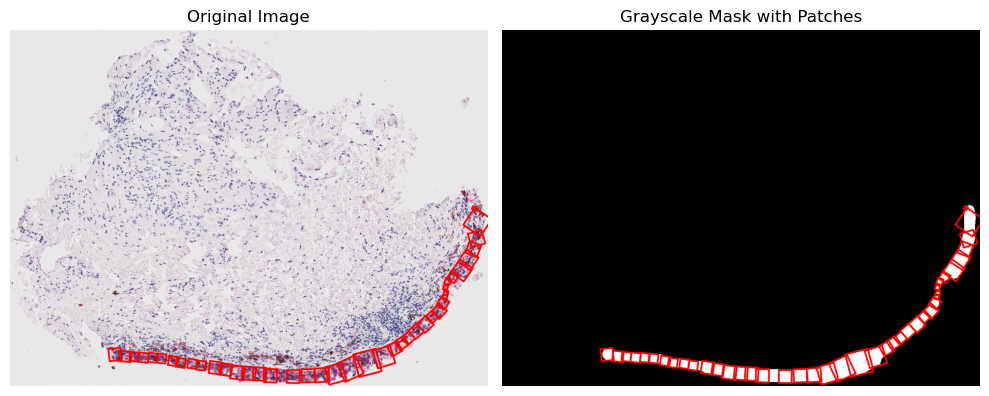

                      Metric        Value
0                num_patches    42.000000
1  total_epithelium_coverage    93.576337
2   background_pixel_percent     8.243456
3                      score    93.212379
4           extension_factor     1.100000
5                  step_size     2.000000
6                  max_width  2048.000000
7          overlap_threshold     0.300000
('testing_slices_fix/case_86_match_1_h&e.png', 'testing_slices_fix/case_86_match_1_h&e.tif')


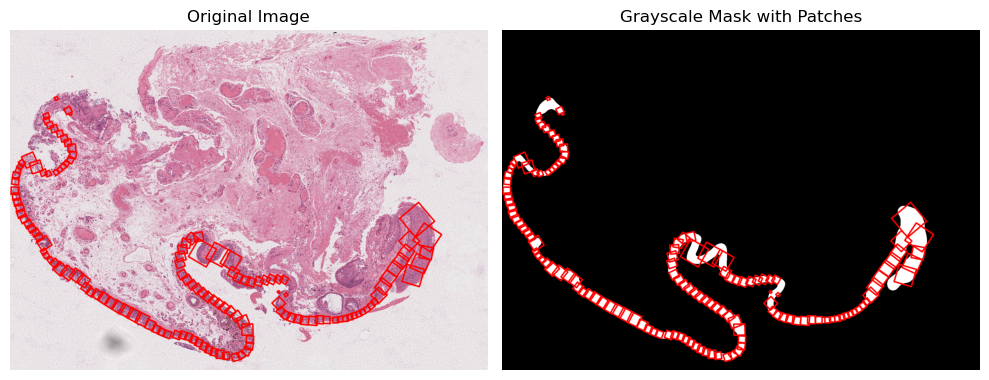

                      Metric        Value
0                num_patches   137.000000
1  total_epithelium_coverage    89.715992
2   background_pixel_percent    14.204677
3                      score    88.931858
4           extension_factor     1.100000
5                  step_size     2.000000
6                  max_width  2048.000000
7          overlap_threshold     0.300000
('testing_slices_fix/case_86_match_1_sox10.png', 'testing_slices_fix/case_86_match_1_sox10.tif')


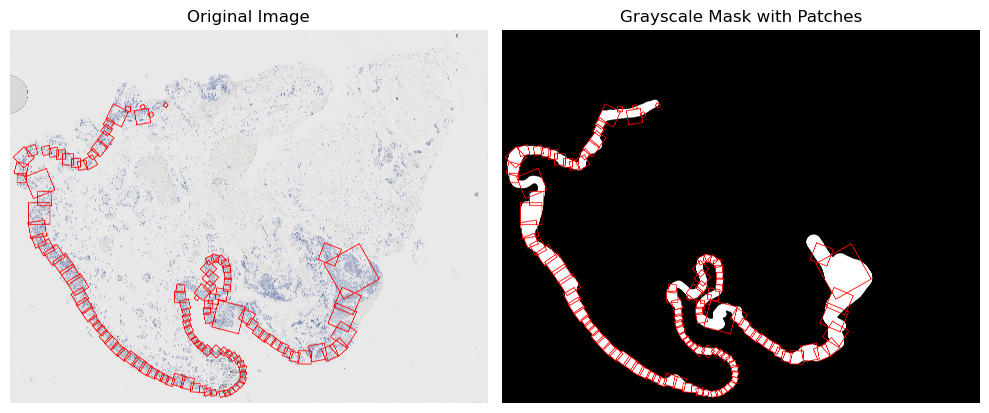

                      Metric        Value
0                num_patches   118.000000
1  total_epithelium_coverage    90.410381
2   background_pixel_percent    15.877024
3                      score    89.152900
4           extension_factor     1.100000
5                  step_size     2.000000
6                  max_width  2048.000000
7          overlap_threshold     0.300000


In [5]:
# Path to your folder
image_folder = "testing_slices_fix" # put folder path here

# Dictionary to store matches
cases = {}

# Iterate over files in the folder
for filename in os.listdir(image_folder):
    match = re.match(r"case_(\d+)_match_(\d+)_(h&e|melan|sox10).*\.(png|tif)", filename)
    if match:
        case_number, match_number, scan_type, extension = match.groups()
        case_number, match_number = int(case_number), int(match_number)  # Convert to int for sorting
        
        if case_number not in cases:
            cases[case_number] = {}

        if match_number not in cases[case_number]:
            cases[case_number][match_number] = {}

        if scan_type not in cases[case_number][match_number]:
            cases[case_number][match_number][scan_type] = {"mask": "None", "slice": "None"}

        if extension == "png":
            cases[case_number][match_number][scan_type]["mask"] = os.path.join(image_folder, filename)
            
        elif extension == "tif":
            cases[case_number][match_number][scan_type]["slice"] = os.path.join(image_folder, filename)

# Build list of tuples (mask, slice), ensuring both exist
matched_pairs = []
masks = []
for case in cases.values():
    for match in case.values():
        for scan in match.values():
            if 'mask' in scan:
                matched_pairs.append((scan['mask'], scan['slice']))


# delete any patches that are already in the directory
empty_folder()

# Run patching and exporting over list of tuples
for i, m in enumerate(matched_pairs, 1):
    print(m)
    image1 = cv2.imread(m[0])
    image1_gray = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    _,whole_thresh1=cv2.threshold(image1_gray,240,255,cv2.THRESH_BINARY_INV)
    if mask_smoothing == True:
        # Compute the smoothed mask.
        smoothed_binary = compute_smoothed_mask(whole_thresh1)
        # Use the smoothed mask in your patching/export pipeline.
        metrics, images = patching_export(smoothed_binary, m[0], m[1])
    else:
        metrics, images = patching_export(whole_thresh1, m[0], m[1])  # (binary, slice_name, slice_details) aka (binary image, epithelium annotation png, tif)
    print(metrics)

# plotting tangents and normals 

In [11]:
# Visualization functions for tangent and normal vectors on mask
def visualize_tangents_on_mask(binary_mask, contours, normals, tangent_length=200, color=(255,0,0), thickness=30, step=90):
    """
    Visualize tangent vectors along contours on the binary mask.
    """
    # Convert binary mask to RGB for colored visualization
    mask_rgb = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2RGB)
    result = mask_rgb.copy()
    
    for contour, contour_normals in zip(contours, normals):
        points = contour.reshape(-1, 2)
        
        for i in range(0, len(points), step):
            if i >= len(contour_normals):  # Safety check
                continue
                
            # Calculate tangent by rotating normal 90 degrees
            tangent = np.array([-contour_normals[i][1], contour_normals[i][0]])
            
            # Scale tangent to desired length
            tangent = tangent * tangent_length / 2
            
            # Calculate start and end points
            start_point = tuple((points[i] - tangent).astype(int))
            end_point = tuple((points[i] + tangent).astype(int))
            
            # Draw the tangent line
            cv2.line(result, start_point, end_point, color, thickness)
    
    return result

def visualize_normals_on_mask(binary_mask, contours, normals, normal_length=200, color=(0,255,0), thickness=30, step=90):
    """
    Visualize normal vectors along contours on the binary mask.
    """
    # Convert binary mask to RGB for colored visualization
    mask_rgb = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2RGB)
    result = mask_rgb.copy()
    
    for contour, contour_normals in zip(contours, normals):
        points = contour.reshape(-1, 2)
        
        for i in range(0, len(points), step):
            if i >= len(contour_normals):  # Safety check
                continue
                
            # Scale normal to desired length
            normal = contour_normals[i] * normal_length
            
            # Calculate end point (start point is the contour point)
            start_point = tuple(points[i].astype(int))
            end_point = tuple((points[i] - normal).astype(int))  # Use negative normal to point inward
            
            # Draw the normal line
            cv2.line(result, start_point, end_point, color, thickness)
    
    return result

def visualize_tangents_and_normals_on_mask(binary_mask, contours, normals, vector_length=200, 
                                          tangent_color=(255,0,0), normal_color=(0,255,0), 
                                          thickness=30, step=90):
    """
    Visualize both tangent and normal vectors on the binary mask.
    """
    # Convert binary mask to RGB for colored visualization
    mask_rgb = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2RGB)
    result = mask_rgb.copy()
    
    for contour, contour_normals in zip(contours, normals):
        points = contour.reshape(-1, 2)
        
        for i in range(0, len(points), step):
            if i >= len(contour_normals):  # Safety check
                continue
                
            # Calculate tangent
            tangent = np.array([-contour_normals[i][1], contour_normals[i][0]])
            tangent = tangent * vector_length / 2
            
            # Draw tangent
            tangent_start = tuple((points[i] - tangent).astype(int))
            tangent_end = tuple((points[i] + tangent).astype(int))
            cv2.line(result, tangent_start, tangent_end, tangent_color, thickness)
            
            # Draw normal
            normal = contour_normals[i] * vector_length
            normal_start = tuple(points[i].astype(int))
            normal_end = tuple((points[i] - normal).astype(int))
            cv2.line(result, normal_start, normal_end, normal_color, thickness)
    
    return result


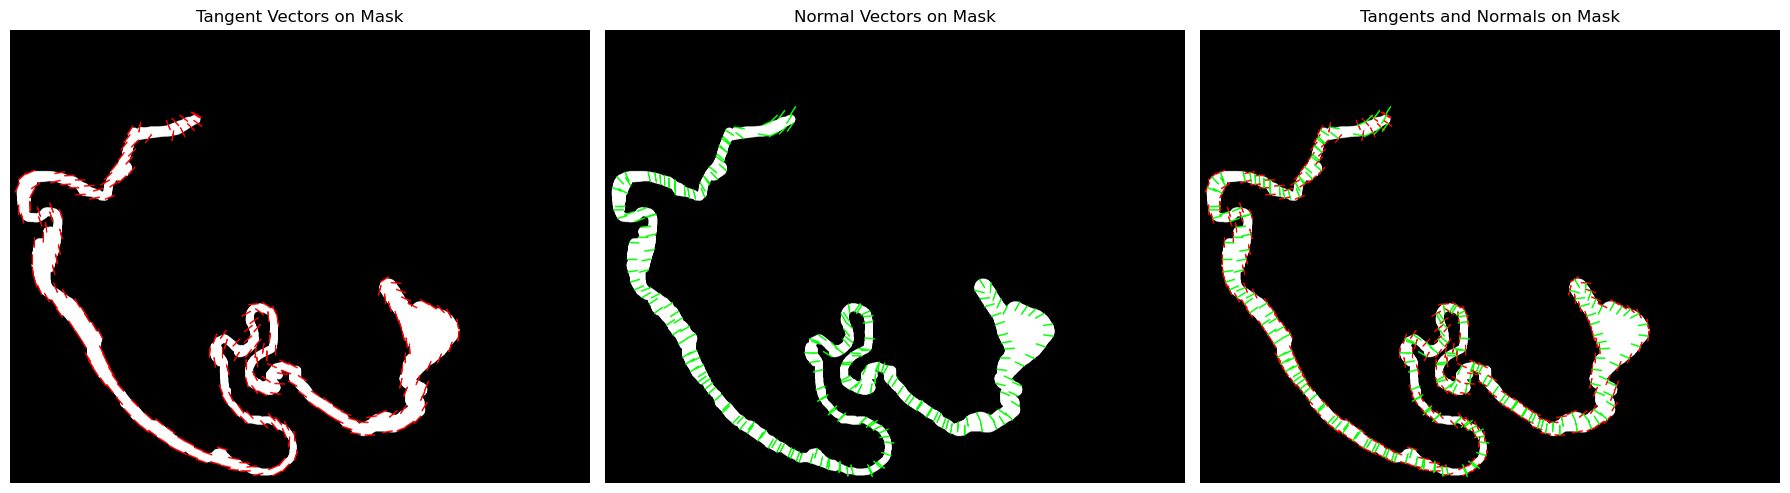

In [12]:
# Load an image and its mask
image_path = "testing_slices_fix/case_86_match_1_sox10.tif"  # Your image file
mask_path = "testing_slices_fix/case_86_match_1_sox10.png"   # Your mask file

# Load and process the image and mask
image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path)
mask_gray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
_, binary_mask = cv2.threshold(mask_gray, 240, 255, cv2.THRESH_BINARY_INV)

# Get contours and normals
contours = get_contours(binary_mask)
normals = better_normals(contours, binary_mask)

# Visualize tangents and normals on the mask
tangents_on_mask = visualize_tangents_on_mask(binary_mask, contours, normals, tangent_length=200, step=120)
normals_on_mask = visualize_normals_on_mask(binary_mask, contours, normals, normal_length=200, step=120)
combined_on_mask = visualize_tangents_and_normals_on_mask(binary_mask, contours, normals, vector_length=200, step=120)

# Display the results
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(tangents_on_mask)
plt.title("Tangent Vectors on Mask")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(normals_on_mask)
plt.title("Normal Vectors on Mask")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(combined_on_mask)
plt.title("Tangents and Normals on Mask")
plt.axis('off')

plt.tight_layout()
plt.show()


In [30]:
def compare_smoothing_parameters(contours, binary_image, show_details=True):
    """
    Compare sigma values between original and improved methods for smoothing.
    
    Args:
        contours: List of contours from get_contours
        binary_image: Binary mask image
        show_details: Whether to print detailed information
        
    Returns:
        DataFrame with comparison of sigma values
    """
    import pandas as pd
    from scipy.signal import argrelextrema
    import numpy as np
    import matplotlib.pyplot as plt
    import cv2
    
    results = []
    
    for i, contour in enumerate(contours):
        points = contour.reshape(-1, 2).astype(np.float32)
        
        # Original method
        original_sigma = max(len(contour) // 90, 1)
        
        # Improved method
        # Calculate complexity
        diffs = np.gradient(points, axis=0)
        curvature = np.linalg.norm(np.gradient(diffs, axis=0), axis=1)
        peaks = argrelextrema(curvature, np.greater)[0]
        complexity = len(peaks) / len(points) if len(points) >= 5 else 1
        improved_sigma = max(len(contour) * complexity // 20, 1)
        
        # Calculate the difference
        sigma_difference = improved_sigma - original_sigma
        sigma_ratio = improved_sigma / original_sigma if original_sigma > 0 else float('inf')
        
        # Store results
        results.append({
            'Contour': i,
            'Contour Length': len(contour),
            'Original Sigma': original_sigma,
            'Complexity': complexity,
            'Improved Sigma': improved_sigma,
            'Difference': sigma_difference,
            'Ratio': sigma_ratio
        })
        
        # Optional detailed analysis
        if show_details:
            # Find highest curvature points
            top_indices = np.argsort(curvature)[-5:]  # Top 5 highest curvature points
            print(f"\nContour {i} (Length: {len(contour)})")
            print(f"Original sigma: {original_sigma}, Improved sigma: {improved_sigma}")
            print(f"Complexity: {complexity:.5f}, Ratio: {sigma_ratio:.2f}x")
            print("\nHighest curvature points:")
            for idx in top_indices:
                point = points[idx]
                print(f"Point {idx}: {point} - Curvature: {curvature[idx]:.4f}")
    
    # Create dataframe
    df = pd.DataFrame(results)
    
    # Show summary
    print("\nSummary Statistics:")
    print(f"Average original sigma: {df['Original Sigma'].mean():.2f}")
    print(f"Average improved sigma: {df['Improved Sigma'].mean():.2f}")
    print(f"Average complexity: {df['Complexity'].mean():.5f}")
    print(f"Average sigma ratio: {df['Ratio'].mean():.2f}x")
    
    # Visualize highest curvature points on the image
    if show_details:
        # Create copy of binary image for visualization
        vis_image = np.zeros((binary_image.shape[0], binary_image.shape[1], 3), dtype=np.uint8)
        vis_image[binary_image > 0] = [255, 255, 255]  # White epithelium
        
        for i, contour in enumerate(contours):
            points = contour.reshape(-1, 2).astype(np.float32)
            
            # Calculate curvature again
            diffs = np.gradient(points, axis=0)
            curvature = np.linalg.norm(np.gradient(diffs, axis=0), axis=1)
            
            # Find high curvature points
            high_curvature = np.zeros_like(curvature, dtype=bool)
            high_curvature[argrelextrema(curvature, np.greater)[0]] = True
            
            # Draw all contour points
            for j, point in enumerate(points):
                x, y = point.astype(int)
                if 0 <= x < binary_image.shape[1] and 0 <= y < binary_image.shape[0]:
                    if high_curvature[j]:
                        # Red for high curvature points, larger size
                        cv2.circle(vis_image, (x, y), 30, (0, 0, 255), -1)
                    else:
                        # Blue for regular contour points, increased size
                        cv2.circle(vis_image, (x, y), 10, (255, 0, 0), -1)
        
        plt.figure(figsize=(20, 20))  # Increased figure size
        plt.imshow(vis_image)
        plt.title("Contour Points (Red) and High Curvature Points (Blue)", fontsize=20)
        plt.axis('off')
        plt.show()
    
    return df




Contour 0 (Length: 26886)
Original sigma: 298, Improved sigma: 49.0
Complexity: 0.03708, Ratio: 0.16x

Highest curvature points:
Point 11623: [7669. 8409.] - Curvature: 51.0055
Point 1987: [ 793. 2969.] - Curvature: 57.5000
Point 1988: [ 792. 2968.] - Curvature: 57.5022
Point 1990: [ 536. 2969.] - Curvature: 61.7500
Point 1989: [ 537. 2968.] - Curvature: 61.7520

Summary Statistics:
Average original sigma: 298.00
Average improved sigma: 49.00
Average complexity: 0.03708
Average sigma ratio: 0.16x


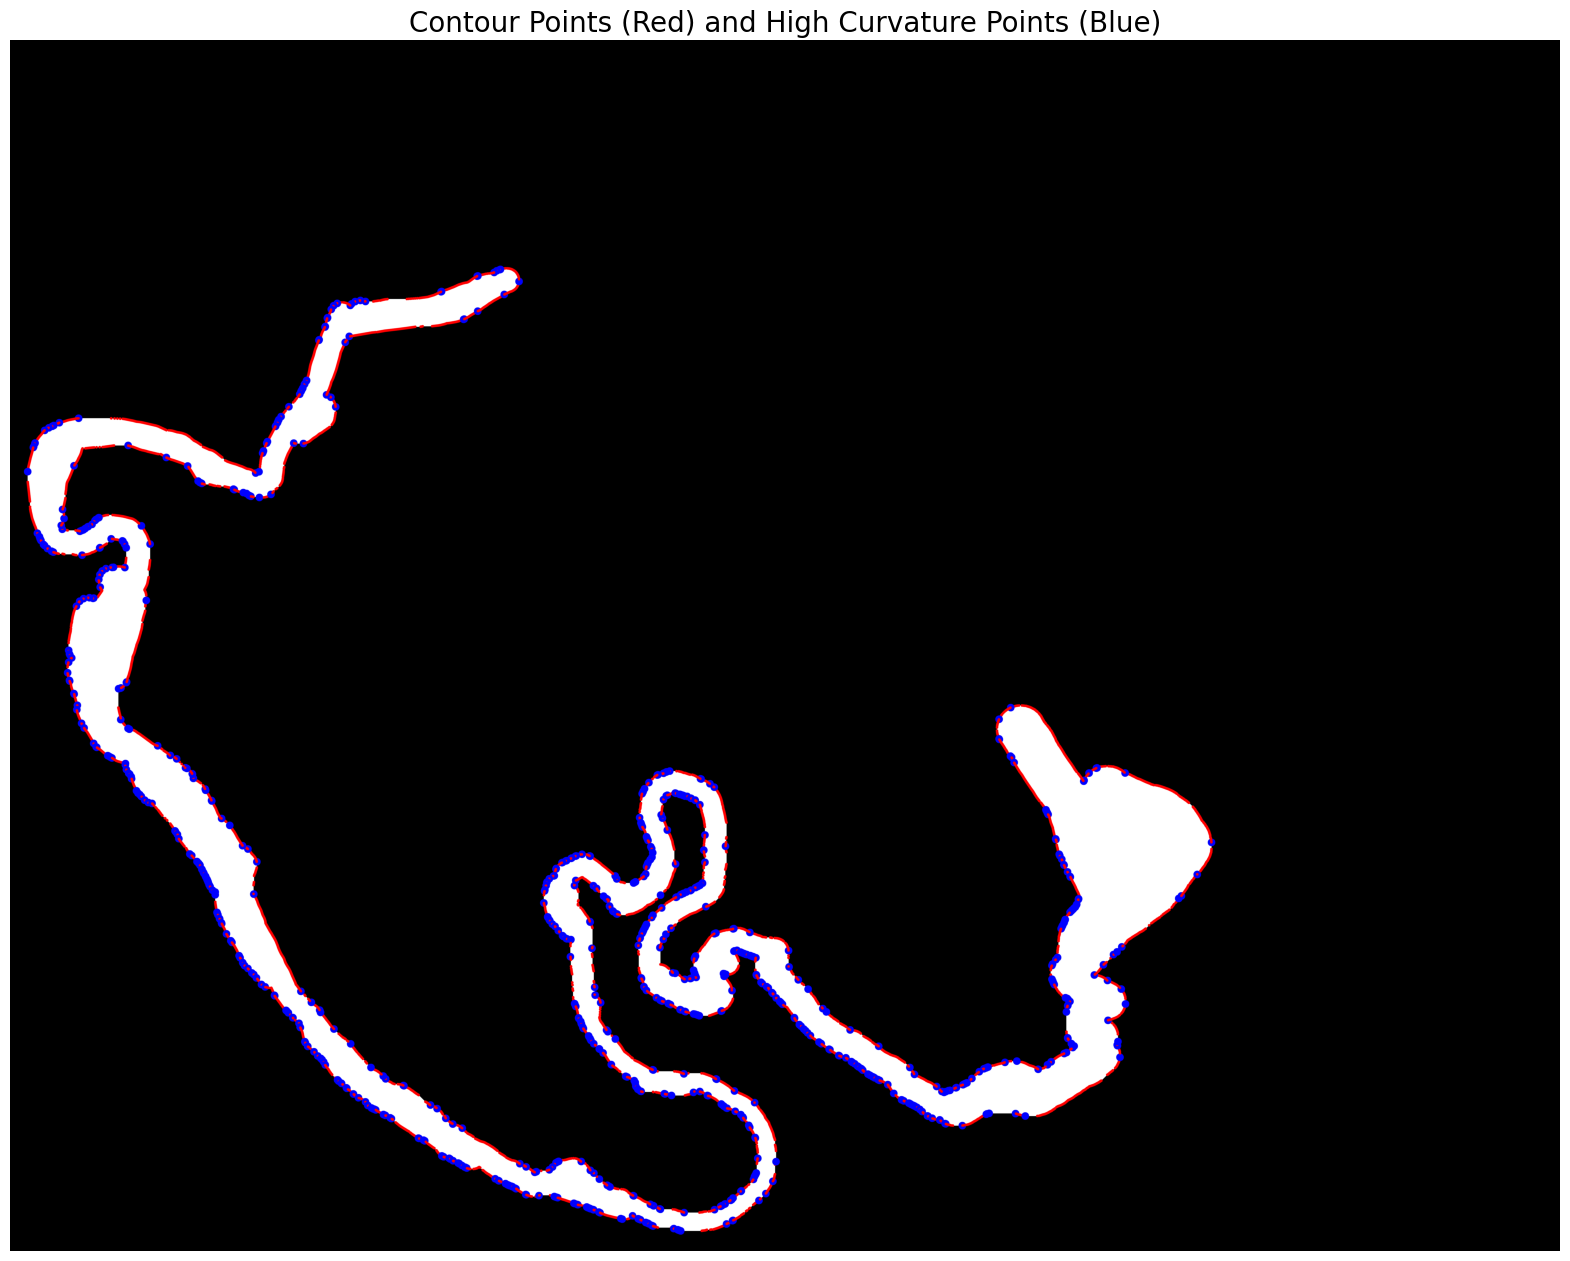

In [31]:
# Load your image and get contours
image = cv2.imread("testing_slices_fix/case_86_match_1_sox10.tif")
mask = cv2.imread("testing_slices_fix/case_86_match_1_sox10.png")
mask_gray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
_, binary_mask = cv2.threshold(mask_gray, 240, 255, cv2.THRESH_BINARY_INV)

# Get contours
contours = get_contours(binary_mask)

# Compare smoothing parameters
comparison_results = compare_smoothing_parameters(contours, binary_mask)


In [ ]:
# Original method
sigmas = np.array([max(len(contour) // 90, 1) for contour in contours])

# Improved method
complexity = estimate_curvature_complexity(points)
sigma = max(len(contour) * complexity // 20, 1)

In [15]:
def visualize_sigma_comparison(original_sigma, improved_sigma, save_path=None):
    """
    Generate a bar chart comparing original and improved sigma values.
    
    Args:
        original_sigma: Sigma value from original method
        improved_sigma: Sigma value from improved method
        save_path: Optional path to save the figure
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create bar chart
    plt.figure(figsize=(8, 6))
    
    # Plot bars
    bars = plt.bar(['Original', 'Improved'], [original_sigma, improved_sigma], 
                  color=['#ff9999', '#66b3ff'], width=0.5)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=14)
    
    # Add title and labels
    plt.title('Comparison of Smoothing Parameters (Sigma)', fontsize=16)
    plt.ylabel('Sigma Value', fontsize=14)
    plt.ylim(0, max(original_sigma, improved_sigma) * 1.15)  # Add some space for labels
    
    # Add annotation explaining significance
    plt.figtext(0.5, 0.01, 
                "The improved method uses more appropriate smoothing parameters\ntailored to the contour's complexity.",
                ha='center', fontsize=12, bbox={"facecolor":"lightgrey", "alpha":0.5, "pad":5})
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Adjust layout for annotation
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()

def compare_smoothed_contours(binary_mask, contours, original_sigma, improved_sigma, save_path=None):
    """
    Visualize the same contour section with different smoothing levels.
    
    Args:
        binary_mask: Binary mask image
        contours: List of contours
        original_sigma: Sigma value from original method
        improved_sigma: Sigma value from improved method
        save_path: Optional path to save the figure
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy.ndimage import gaussian_filter1d
    
    # Select the first contour (or you can choose a specific one)
    contour = contours[0]
    points = contour.reshape(-1, 2).astype(np.float32)
    
    # Find a high-curvature section to focus on
    # Calculate curvature
    diffs = np.gradient(points, axis=0)
    curvature = np.linalg.norm(np.gradient(diffs, axis=0), axis=1)
    
    # Find high curvature points
    from scipy.signal import argrelextrema
    high_curvature_indices = argrelextrema(curvature, np.greater)[0]
    
    # Choose one of the high curvature points
    if len(high_curvature_indices) > 0:
        # Sort by curvature value to get the highest
        idx = high_curvature_indices[np.argsort(curvature[high_curvature_indices])[-1]]
    else:
        # If no high curvature points found, just use the middle of the contour
        idx = len(points) // 2
    
    # Get a section around this point (+/- 100 points)
    section_start = max(0, idx - 100)
    section_end = min(len(points), idx + 101)
    section = points[section_start:section_end]
    
    # Apply both smoothing methods
    original_smoothed = gaussian_filter1d(section, original_sigma/10, axis=0)  # Divide by 10 to make difference visible
    improved_smoothed = gaussian_filter1d(section, improved_sigma, axis=0)
    
    # Create visualization
    plt.figure(figsize=(12, 6))
    
    # Plot original contour section
    plt.subplot(1, 2, 1)
    plt.plot(section[:, 0], section[:, 1], 'k-', linewidth=1, alpha=0.5, label='Original Contour')
    plt.plot(original_smoothed[:, 0], original_smoothed[:, 1], 'r-', linewidth=3, label=f'Smoothed (σ={original_sigma:.0f})')
    plt.title(f'Original Method Smoothing\n(σ={original_sigma:.0f})', fontsize=14)
    plt.legend()
    plt.axis('equal')
    
    # Plot improved contour section
    plt.subplot(1, 2, 2)
    plt.plot(section[:, 0], section[:, 1], 'k-', linewidth=1, alpha=0.5, label='Original Contour')
    plt.plot(improved_smoothed[:, 0], improved_smoothed[:, 1], 'b-', linewidth=3, label=f'Smoothed (σ={improved_sigma:.0f})')
    plt.title(f'Improved Method Smoothing\n(σ={improved_sigma:.0f})', fontsize=14)
    plt.legend()
    plt.axis('equal')
    
    # Add annotation
    plt.figtext(0.5, 0.01, 
                "The improved method better preserves important contour features\nwhile still providing adequate smoothing.",
                ha='center', fontsize=12, bbox={"facecolor":"lightgrey", "alpha":0.5, "pad":5})
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Adjust layout for annotation
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()


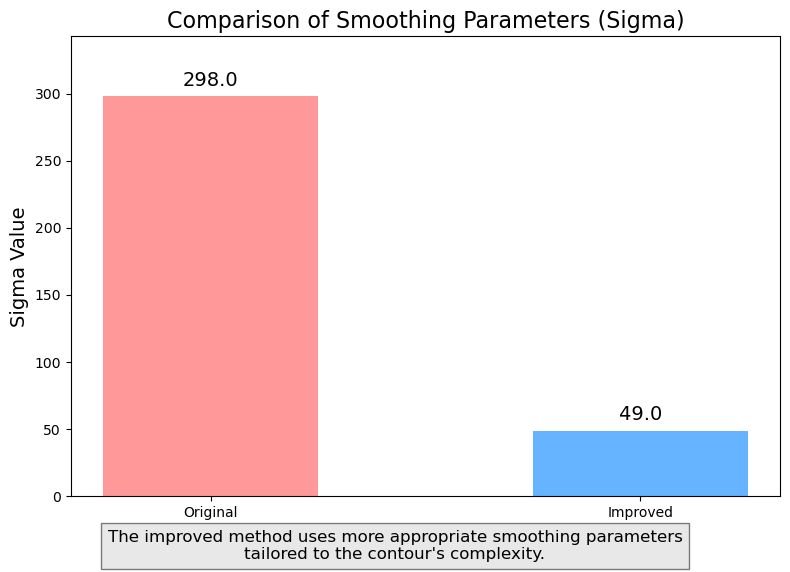

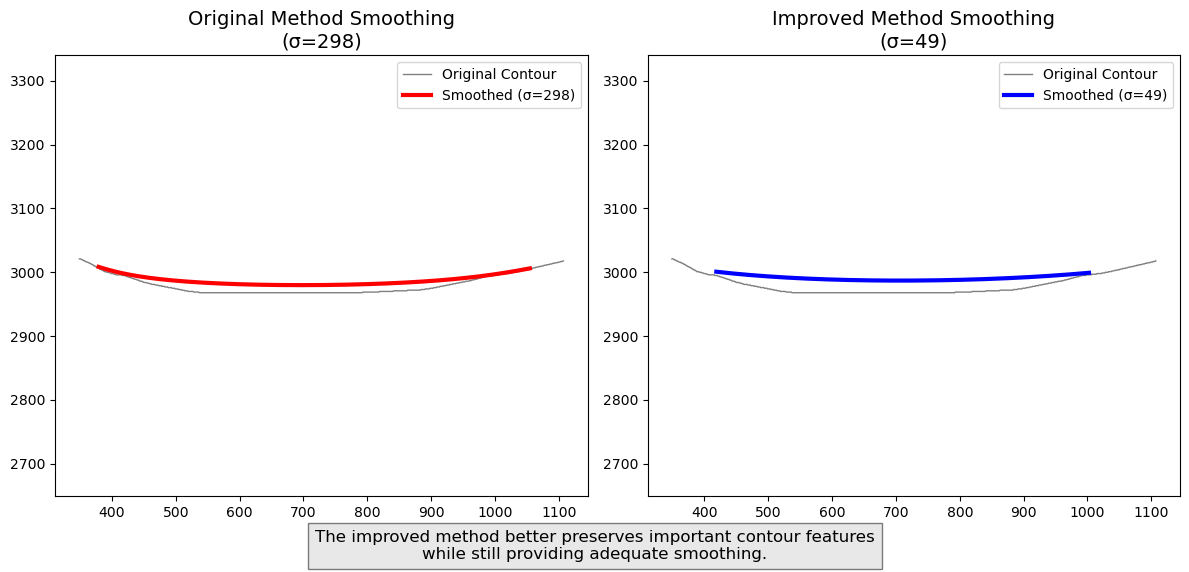

In [16]:
# Get sigma values from your previous analysis
original_sigma = 298
improved_sigma = 49

# Generate bar chart
visualize_sigma_comparison(original_sigma, improved_sigma, save_path='sigma_comparison.png')

# Generate smoothed contour visualization
# First load your image and get contours
image = cv2.imread("testing_slices_fix/case_86_match_1_sox10.tif")
mask = cv2.imread("testing_slices_fix/case_86_match_1_sox10.png")
mask_gray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
_, binary_mask = cv2.threshold(mask_gray, 240, 255, cv2.THRESH_BINARY_INV)
contours = get_contours(binary_mask)

# Generate smoothed contour comparison
compare_smoothed_contours(binary_mask, contours, original_sigma, improved_sigma, save_path='smoothed_contours.png')


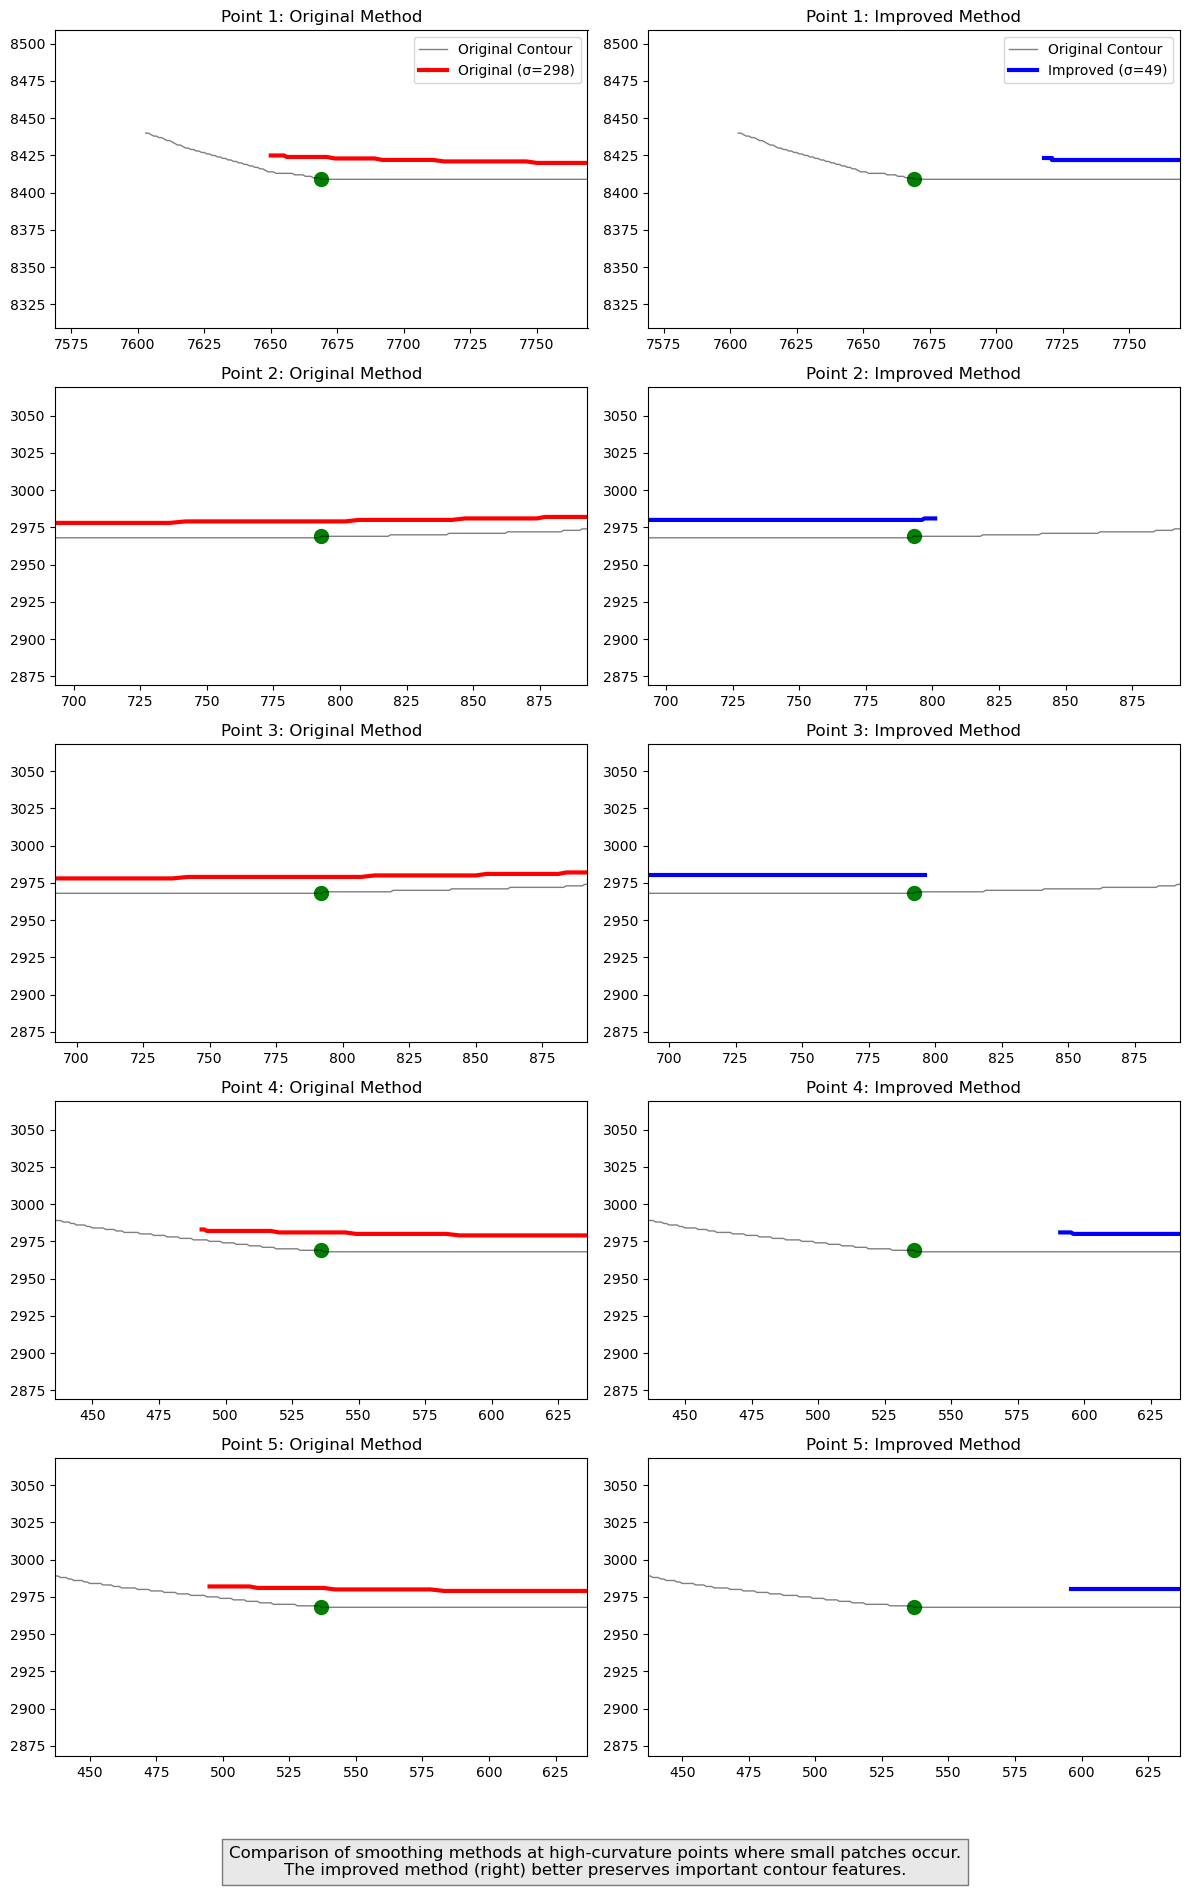

In [17]:
def compare_smoothed_contours_at_points(binary_mask, contours, points_of_interest, 
                                        original_sigma, improved_sigma, window_size=100, save_path=None):
    """
    Visualize smoothed contours at specific high-curvature points.
    
    Args:
        binary_mask: Binary mask image
        contours: List of contours
        points_of_interest: List of [x, y] coordinates to examine
        original_sigma, improved_sigma: Sigma values to compare
        window_size: Size of area to show around each point
        save_path: Optional path to save the figure
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy.ndimage import gaussian_filter1d
    
    # Set up the figure
    fig, axes = plt.subplots(len(points_of_interest), 2, figsize=(12, 4*len(points_of_interest)))
    
    for i, point in enumerate(points_of_interest):
        target_x, target_y = point
        
        # Find closest contour and point to target
        min_dist = float('inf')
        best_contour_idx = 0
        best_point_idx = 0
        
        for c_idx, contour in enumerate(contours):
            points = contour.reshape(-1, 2)
            distances = np.sqrt(np.sum((points - [target_x, target_y])**2, axis=1))
            min_idx = np.argmin(distances)
            if distances[min_idx] < min_dist:
                min_dist = distances[min_idx]
                best_contour_idx = c_idx
                best_point_idx = min_idx
        
        # Get the relevant contour and extract section
        contour = contours[best_contour_idx].reshape(-1, 2)
        section_start = max(0, best_point_idx - 50)
        section_end = min(len(contour), best_point_idx + 51)
        section = contour[section_start:section_end]
        
        # Apply smoothing
        original_smoothed = gaussian_filter1d(section, original_sigma/10, axis=0)  # Scaled for visibility
        improved_smoothed = gaussian_filter1d(section, improved_sigma, axis=0)
        
        # Plot original smoothing
        if len(points_of_interest) == 1:
            ax1 = axes[0]
            ax2 = axes[1]
        else:
            ax1 = axes[i, 0]
            ax2 = axes[i, 1]
            
        # Original method
        ax1.plot(section[:, 0], section[:, 1], 'k-', linewidth=1, alpha=0.5, label='Original Contour')
        ax1.plot(original_smoothed[:, 0], original_smoothed[:, 1], 'r-', linewidth=3, 
                 label=f'Original (σ={original_sigma})')
        ax1.scatter(contour[best_point_idx, 0], contour[best_point_idx, 1], c='green', s=100)
        ax1.set_title(f'Point {i+1}: Original Method', fontsize=12)
        
        # Set axis limits to zoom on problem area
        ax1.set_xlim(target_x - window_size, target_x + window_size)
        ax1.set_ylim(target_y - window_size, target_y + window_size)
        if i == 0:
            ax1.legend()
        
        # Improved method
        ax2.plot(section[:, 0], section[:, 1], 'k-', linewidth=1, alpha=0.5, label='Original Contour')
        ax2.plot(improved_smoothed[:, 0], improved_smoothed[:, 1], 'b-', linewidth=3, 
                 label=f'Improved (σ={improved_sigma})')
        ax2.scatter(contour[best_point_idx, 0], contour[best_point_idx, 1], c='green', s=100)
        ax2.set_title(f'Point {i+1}: Improved Method', fontsize=12)
        
        # Set same axis limits
        ax2.set_xlim(target_x - window_size, target_x + window_size)
        ax2.set_ylim(target_y - window_size, target_y + window_size)
        if i == 0:
            ax2.legend()
    
    plt.figtext(0.5, 0.01, 
                "Comparison of smoothing methods at high-curvature points where small patches occur.\n" +
                "The improved method (right) better preserves important contour features.",
                ha='center', fontsize=12, bbox={"facecolor":"lightgrey", "alpha":0.5, "pad":5})
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()
    
    return fig

# Define high curvature points from your analysis
high_curvature_points = [
    [7669, 8409],  # Point 11623
    [793, 2969],   # Point 1987
    [792, 2968],   # Point 1988
    [536, 2969],   # Point 1990
    [537, 2968]    # Point 1989
]

# Load binary mask and get contours if not already loaded
# image = cv2.imread("testing_slices_fix/case_86_match_1_sox10.tif")
# mask = cv2.imread("testing_slices_fix/case_86_match_1_sox10.png")
# mask_gray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
# _, binary_mask = cv2.threshold(mask_gray, 240, 255, cv2.THRESH_BINARY_INV)
# contours = get_contours(binary_mask)

# Plot comparison at all high curvature points
compare_fig = compare_smoothed_contours_at_points(
    binary_mask, contours, high_curvature_points,
    original_sigma=298, improved_sigma=49,
    save_path='smoothing_comparison.png'
)



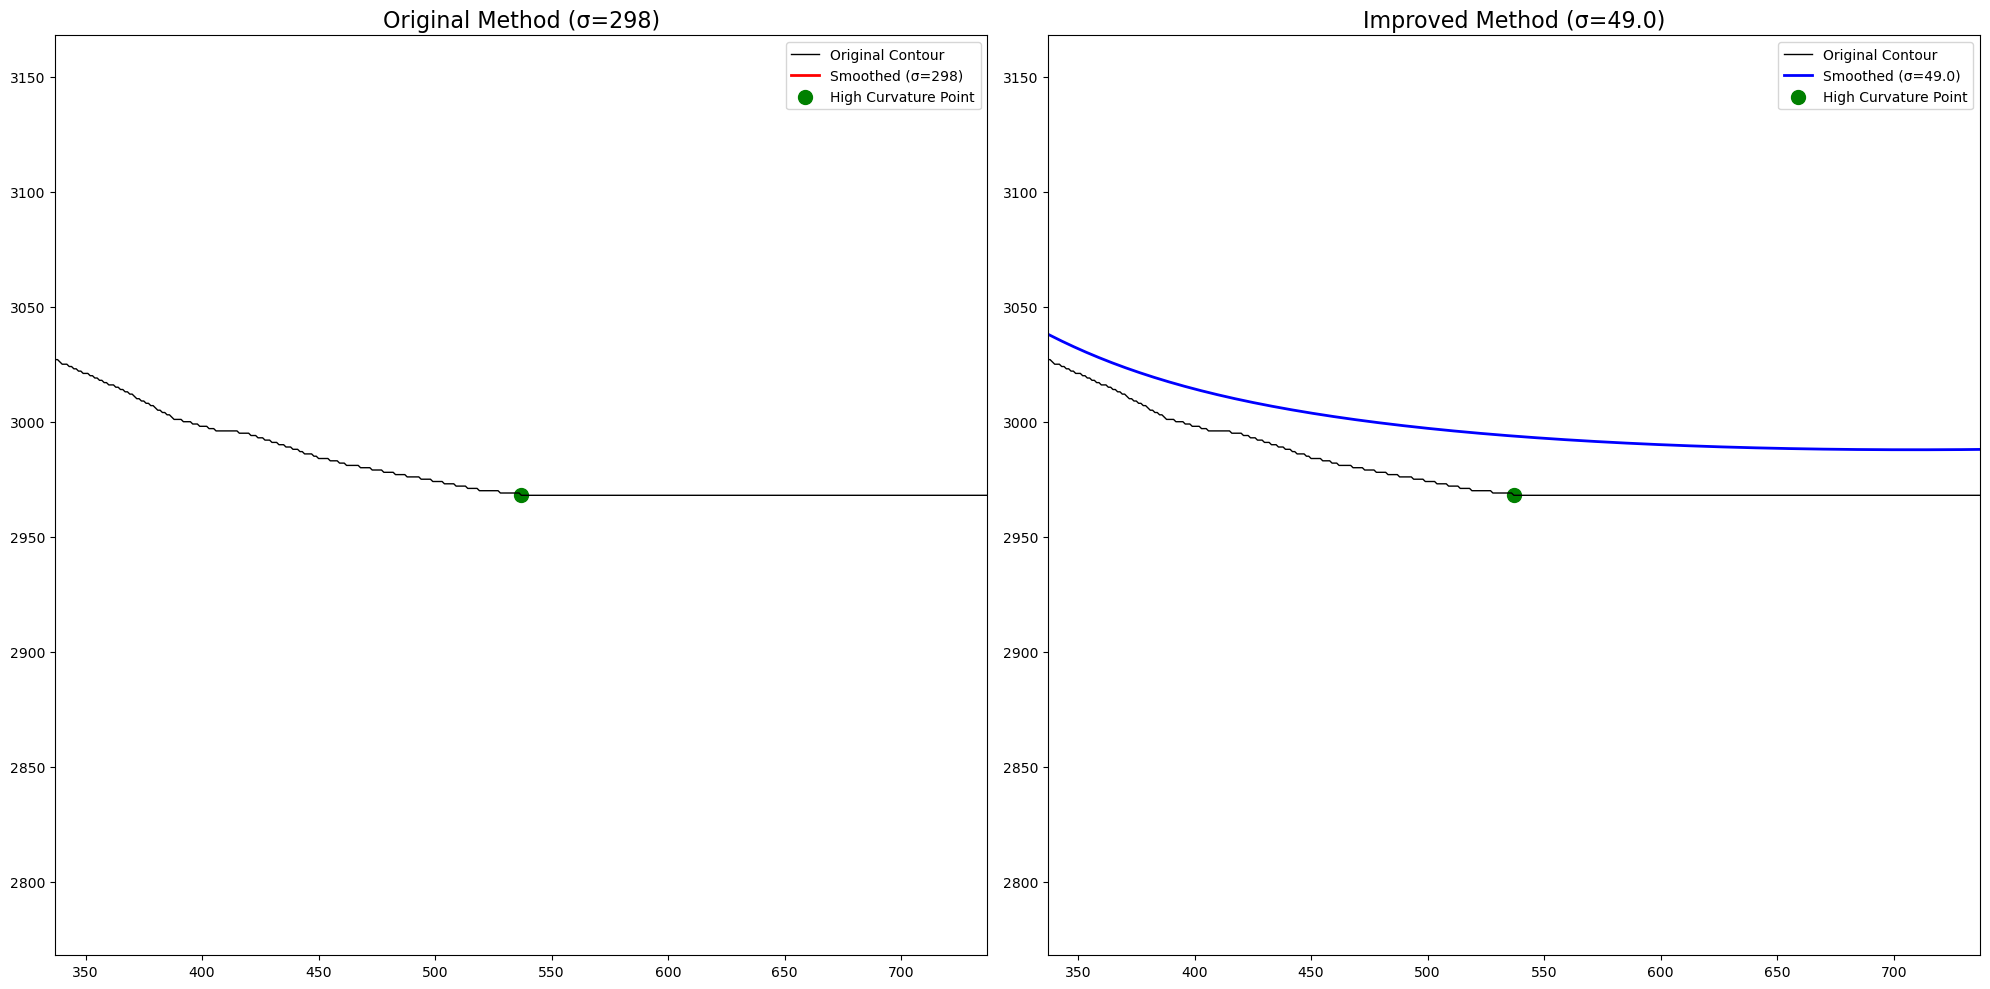

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import argrelextrema

def estimate_curvature_complexity(points):
    """Estimate complexity of contour based on curvature variations"""
    if len(points) < 5:
        return 1
    
    diffs = np.gradient(points, axis=0)
    curvature = np.linalg.norm(np.gradient(diffs, axis=0), axis=1)
    
    # Count number of local maxima in curvature (sharp points)
    peaks = argrelextrema(curvature, np.greater)[0]
    
    # Return peaks/points ratio as measure of complexity
    return len(peaks) / len(points)

def visualize_smoothed_contours(contour, original_sigma, improved_sigma, window_size=200):
    """
    Visualize original and smoothed contours for both methods.
    
    Args:
    contour: numpy array of shape (N, 1, 2) representing the contour
    original_sigma: sigma value for the original method
    improved_sigma: sigma value for the improved method
    window_size: size of the window to zoom in on high curvature points
    """
    # Reshape contour and convert to float
    points = contour.reshape(-1, 2).astype(np.float32)
    
    # Apply smoothing
    original_smoothed = np.column_stack((
        gaussian_filter1d(points[:, 0], original_sigma, mode='wrap'),
        gaussian_filter1d(points[:, 1], original_sigma, mode='wrap')
    ))
    improved_smoothed = np.column_stack((
        gaussian_filter1d(points[:, 0], improved_sigma, mode='wrap'),
        gaussian_filter1d(points[:, 1], improved_sigma, mode='wrap')
    ))
    
    # Calculate curvature to find high curvature points
    diffs = np.gradient(points, axis=0)
    curvature = np.linalg.norm(np.gradient(diffs, axis=0), axis=1)
    high_curvature_idx = np.argmax(curvature)
    
    # Set up the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Plot for original method
    ax1.plot(points[:, 0], points[:, 1], 'k-', linewidth=1, label='Original Contour')
    ax1.plot(original_smoothed[:, 0], original_smoothed[:, 1], 'r-', linewidth=2, label=f'Smoothed (σ={original_sigma})')
    ax1.scatter(points[high_curvature_idx, 0], points[high_curvature_idx, 1], c='g', s=100, label='High Curvature Point')
    ax1.set_title(f'Original Method (σ={original_sigma})', fontsize=16)
    ax1.legend()
    
    # Plot for improved method
    ax2.plot(points[:, 0], points[:, 1], 'k-', linewidth=1, label='Original Contour')
    ax2.plot(improved_smoothed[:, 0], improved_smoothed[:, 1], 'b-', linewidth=2, label=f'Smoothed (σ={improved_sigma})')
    ax2.scatter(points[high_curvature_idx, 0], points[high_curvature_idx, 1], c='g', s=100, label='High Curvature Point')
    ax2.set_title(f'Improved Method (σ={improved_sigma})', fontsize=16)
    ax2.legend()
    
    # Zoom in on the high curvature point
    ax1.set_xlim(points[high_curvature_idx, 0] - window_size, points[high_curvature_idx, 0] + window_size)
    ax1.set_ylim(points[high_curvature_idx, 1] - window_size, points[high_curvature_idx, 1] + window_size)
    ax2.set_xlim(points[high_curvature_idx, 0] - window_size, points[high_curvature_idx, 0] + window_size)
    ax2.set_ylim(points[high_curvature_idx, 1] - window_size, points[high_curvature_idx, 1] + window_size)
    
    plt.tight_layout()
    plt.show()

# After you've processed your image and obtained contours
contours = get_contours(binary_mask)

# Calculate sigma values
original_sigma = max(len(contours[0]) // 90, 1)
complexity = estimate_curvature_complexity(contours[0].reshape(-1, 2))
improved_sigma = max(len(contours[0]) * complexity // 20, 1)

# Visualize the smoothed contours
visualize_smoothed_contours(contours[0], original_sigma, improved_sigma)


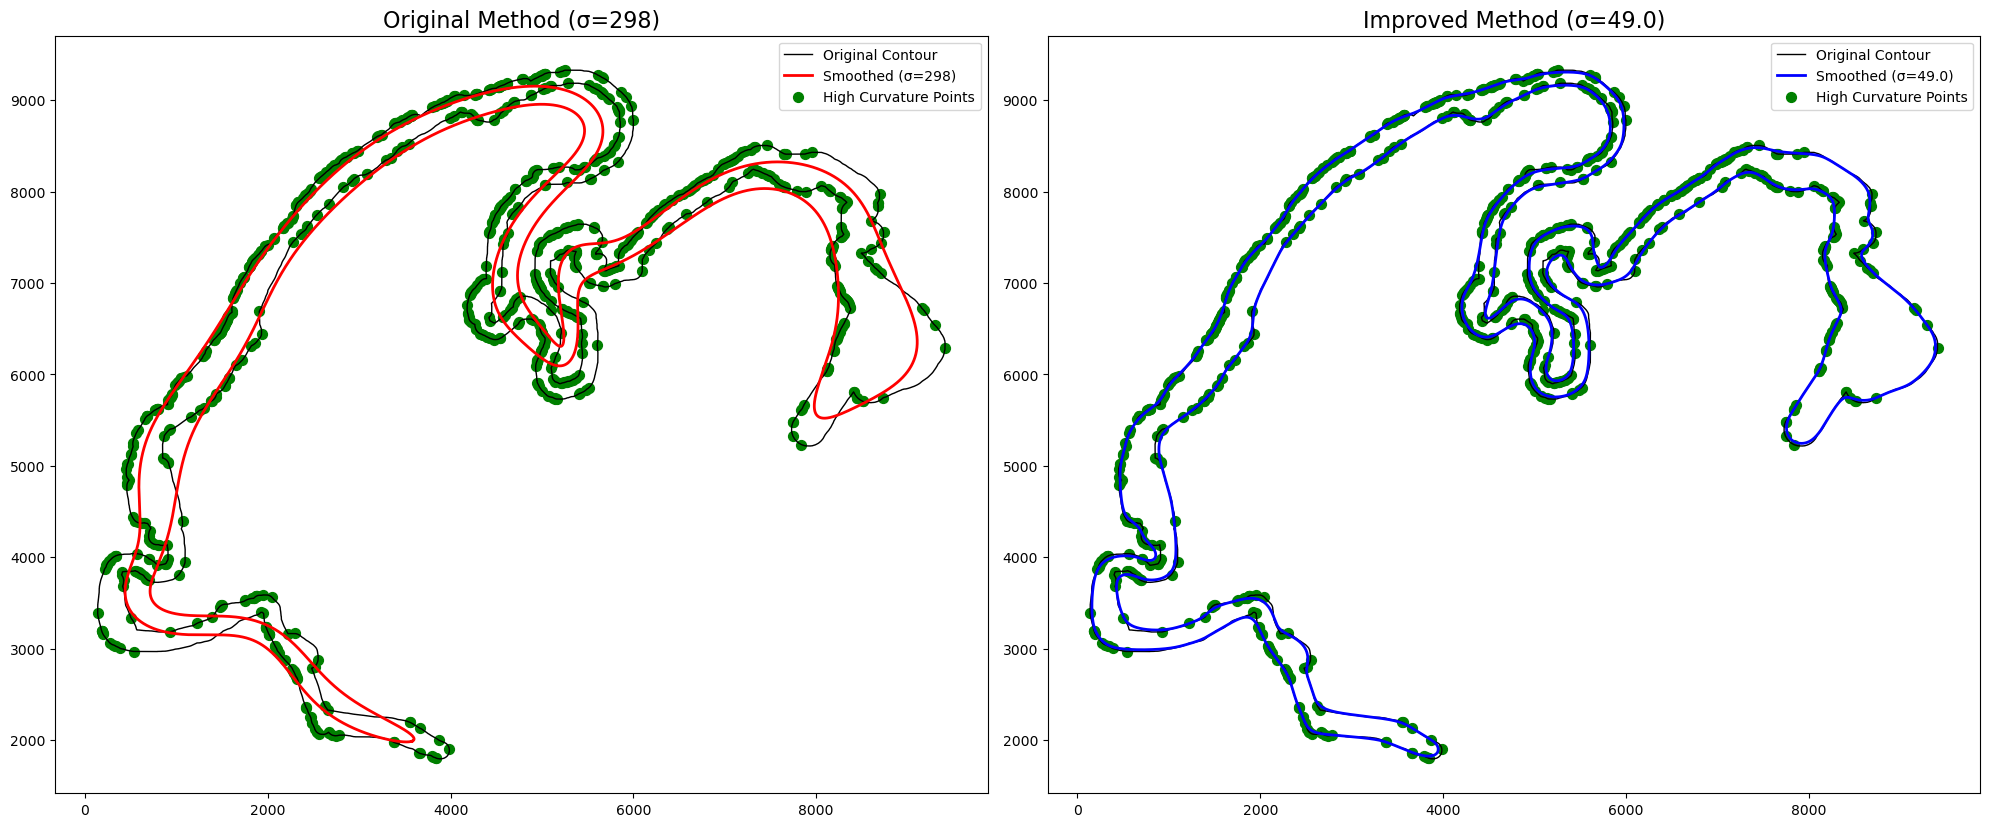

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import argrelextrema

def estimate_curvature_complexity(points):
    """Estimate complexity of contour based on curvature variations"""
    if len(points) < 5:
        return 1
    
    diffs = np.gradient(points, axis=0)
    curvature = np.linalg.norm(np.gradient(diffs, axis=0), axis=1)
    
    # Count number of local maxima in curvature (sharp points)
    peaks = argrelextrema(curvature, np.greater)[0]
    
    # Return peaks/points ratio as measure of complexity
    return len(peaks) / len(points)

def visualize_smoothed_contours(contour, original_sigma, improved_sigma):
    """
    Visualize original and smoothed contours for both methods over the entire contour.
    
    Args:
    contour: numpy array of shape (N, 1, 2) representing the contour
    original_sigma: sigma value for the original method
    improved_sigma: sigma value for the improved method
    """
    # Reshape contour and convert to float
    points = contour.reshape(-1, 2).astype(np.float32)
    
    # Apply smoothing
    original_smoothed = np.column_stack((
        gaussian_filter1d(points[:, 0], original_sigma, mode='wrap'),
        gaussian_filter1d(points[:, 1], original_sigma, mode='wrap')
    ))
    improved_smoothed = np.column_stack((
        gaussian_filter1d(points[:, 0], improved_sigma, mode='wrap'),
        gaussian_filter1d(points[:, 1], improved_sigma, mode='wrap')
    ))
    
    # Calculate curvature to find high curvature points
    diffs = np.gradient(points, axis=0)
    curvature = np.linalg.norm(np.gradient(diffs, axis=0), axis=1)
    high_curvature_indices = argrelextrema(curvature, np.greater)[0]
    
    # Set up the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Plot for original method
    ax1.plot(points[:, 0], points[:, 1], 'k-', linewidth=1, label='Original Contour')
    ax1.plot(original_smoothed[:, 0], original_smoothed[:, 1], 'r-', linewidth=2, label=f'Smoothed (σ={original_sigma})')
    ax1.scatter(points[high_curvature_indices, 0], points[high_curvature_indices, 1], c='g', s=50, label='High Curvature Points')
    ax1.set_title(f'Original Method (σ={original_sigma})', fontsize=16)
    ax1.legend()
    
    # Plot for improved method
    ax2.plot(points[:, 0], points[:, 1], 'k-', linewidth=1, label='Original Contour')
    ax2.plot(improved_smoothed[:, 0], improved_smoothed[:, 1], 'b-', linewidth=2, label=f'Smoothed (σ={improved_sigma})')
    ax2.scatter(points[high_curvature_indices, 0], points[high_curvature_indices, 1], c='g', s=50, label='High Curvature Points')
    ax2.set_title(f'Improved Method (σ={improved_sigma})', fontsize=16)
    ax2.legend()
    
    # Set aspect ratio to equal for both plots
    ax1.set_aspect('equal', 'box')
    ax2.set_aspect('equal', 'box')
    
    plt.tight_layout()
    plt.show()

# After you've processed your image and obtained contours
contours = get_contours(binary_mask)

# Calculate sigma values
original_sigma = max(len(contours[0]) // 90, 1)
complexity = estimate_curvature_complexity(contours[0].reshape(-1, 2))
improved_sigma = max(len(contours[0]) * complexity // 20, 1)

# Visualize the smoothed contours
visualize_smoothed_contours(contours[0], original_sigma, improved_sigma)



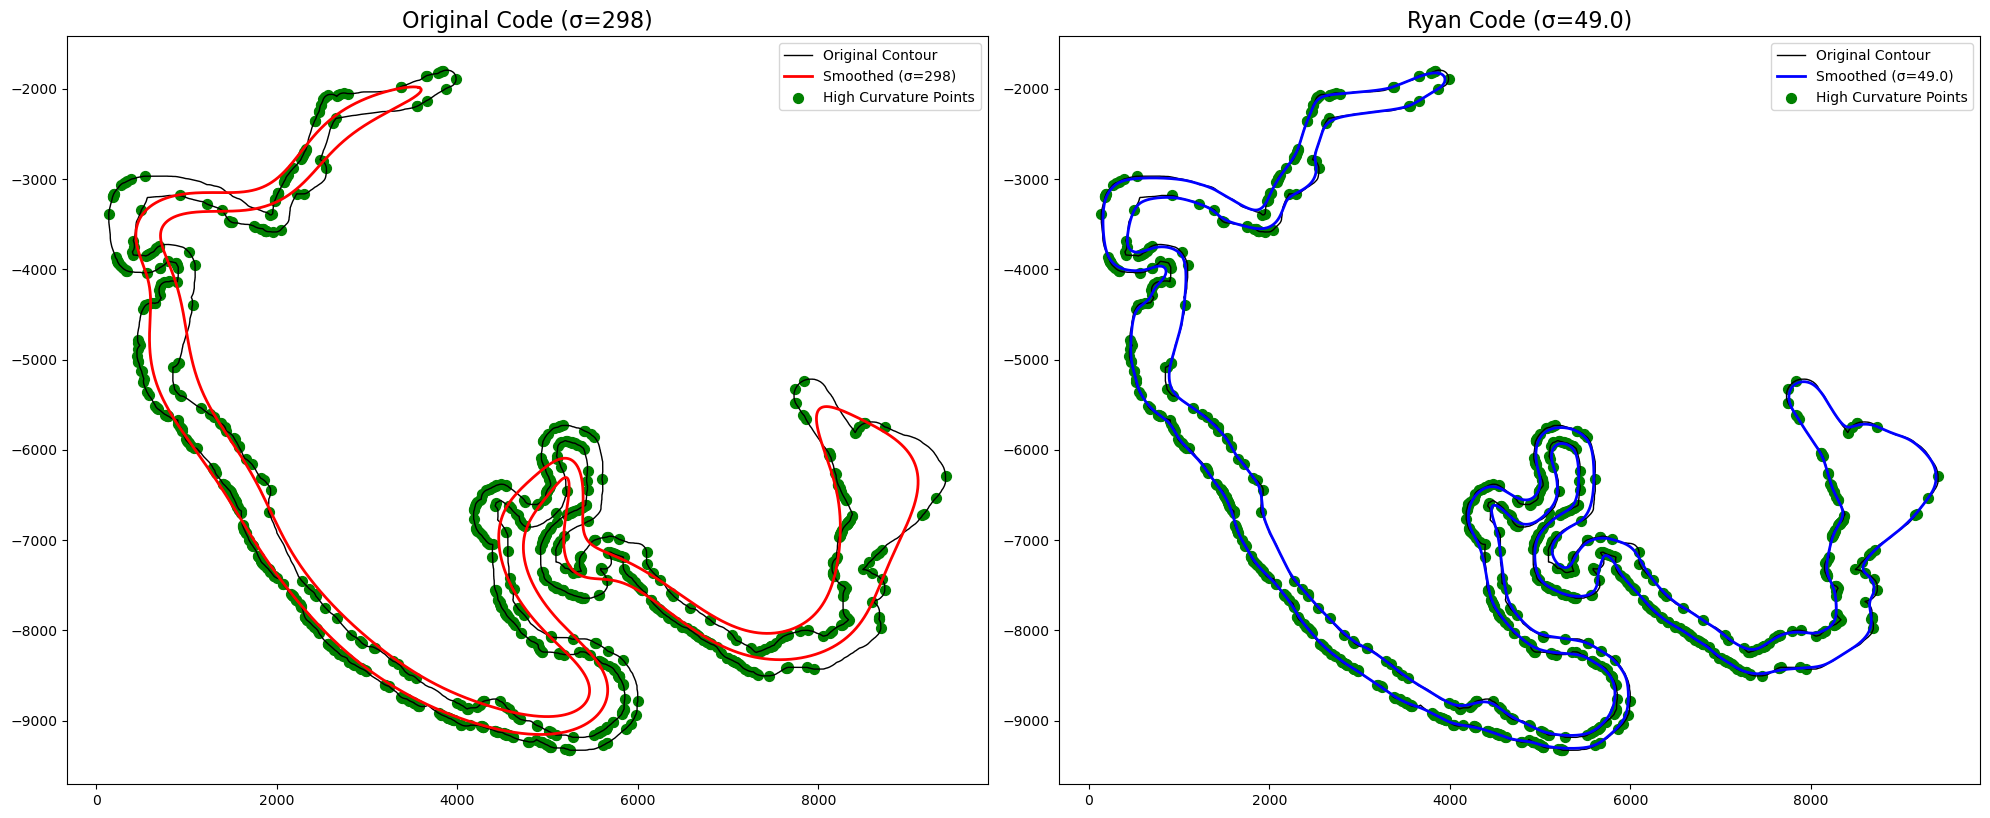

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import argrelextrema

def estimate_curvature_complexity(points):
    """Estimate complexity of contour based on curvature variations"""
    if len(points) < 5:
        return 1
    
    diffs = np.gradient(points, axis=0)
    curvature = np.linalg.norm(np.gradient(diffs, axis=0), axis=1)
    
    # Count number of local maxima in curvature (sharp points)
    peaks = argrelextrema(curvature, np.greater)[0]
    
    # Return peaks/points ratio as measure of complexity
    return len(peaks) / len(points)

def visualize_smoothed_contours(contour, original_sigma, improved_sigma):
    """
    Visualize original and smoothed contours for both methods over the entire contour,
    with correct orientation.
    
    Args:
    contour: numpy array of shape (N, 1, 2) representing the contour
    original_sigma: sigma value for the original method
    improved_sigma: sigma value for the improved method
    """
    # Reshape contour and convert to float
    points = contour.reshape(-1, 2).astype(np.float32)
    
    # Apply smoothing
    original_smoothed = np.column_stack((
        gaussian_filter1d(points[:, 0], original_sigma, mode='wrap'),
        gaussian_filter1d(points[:, 1], original_sigma, mode='wrap')
    ))
    improved_smoothed = np.column_stack((
        gaussian_filter1d(points[:, 0], improved_sigma, mode='wrap'),
        gaussian_filter1d(points[:, 1], improved_sigma, mode='wrap')
    ))
    
    # Calculate curvature to find high curvature points
    diffs = np.gradient(points, axis=0)
    curvature = np.linalg.norm(np.gradient(diffs, axis=0), axis=1)
    high_curvature_indices = argrelextrema(curvature, np.greater)[0]
    
    # Set up the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Plot for original method
    ax1.plot(points[:, 0], -points[:, 1], 'k-', linewidth=1, label='Original Contour')
    ax1.plot(original_smoothed[:, 0], -original_smoothed[:, 1], 'r-', linewidth=2, label=f'Smoothed (σ={original_sigma})')
    ax1.scatter(points[high_curvature_indices, 0], -points[high_curvature_indices, 1], c='g', s=50, label='High Curvature Points')
    ax1.set_title(f'Original Code (σ={original_sigma})', fontsize=16)
    ax1.legend()
    
    # Plot for improved method
    ax2.plot(points[:, 0], -points[:, 1], 'k-', linewidth=1, label='Original Contour')
    ax2.plot(improved_smoothed[:, 0], -improved_smoothed[:, 1], 'b-', linewidth=2, label=f'Smoothed (σ={improved_sigma})')
    ax2.scatter(points[high_curvature_indices, 0], -points[high_curvature_indices, 1], c='g', s=50, label='High Curvature Points')
    ax2.set_title(f'Ryan Code (σ={improved_sigma})', fontsize=16)
    ax2.legend()
    
    # Set aspect ratio to equal for both plots
    ax1.set_aspect('equal', 'box')
    ax2.set_aspect('equal', 'box')
    
    plt.tight_layout()
    plt.show()

# Usage
contours = get_contours(binary_mask)
original_sigma = max(len(contours[0]) // 90, 1)
complexity = estimate_curvature_complexity(contours[0].reshape(-1, 2))
improved_sigma = max(len(contours[0]) * complexity // 20, 1)
visualize_smoothed_contours(contours[0], original_sigma, improved_sigma)
